# Import PyTorch

In [47]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.13.0+cu126
True
NVIDIA GeForce RTX 4070 SUPER


# Setup GPU as device

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Load dataset

In [49]:
from torchvision import datasets
from torchvision.transforms import ToTensor

train_data = datasets.MNIST(
    root="data",
    train=True,
    transform=ToTensor(),
    download=True
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    transform=ToTensor()
)

In [50]:
print(f"Train dataset size: {len(train_data)}\nTest dataset size: {len(test_data)}")
print(f"Data shape: {train_data[0][0].shape} and first label is {train_data[0][1]}")

Train dataset size: 60000
Test dataset size: 10000
Data shape: torch.Size([1, 28, 28]) and first label is 5


# Vizualize a few examples

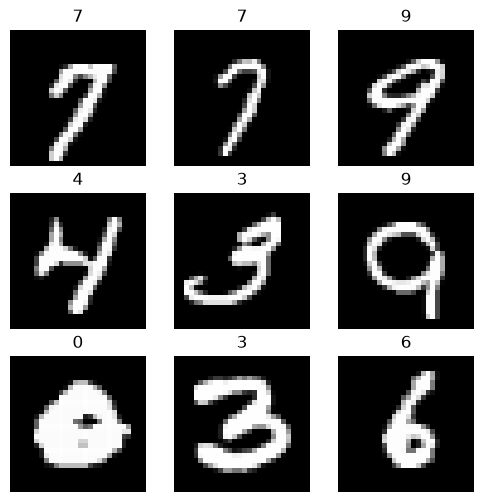

In [51]:
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(6, 6))

cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

# Create Dataloader

In [52]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    train_data, 
    batch_size=64, 
    shuffle=True
)

test_dataloader = DataLoader(
    test_data, 
    batch_size=64, 
    shuffle=False
)

In [53]:
images, labels = next(iter(train_dataloader))
print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


## Note
torch.Size([64, 1, 28, 28])
64 => elements in batch
1 => canal, MNIST use gray-scale so the canal is 1
28, 28 => height and width

# Create a model and train the model

In [ ]:
import torch.nn as nn
import torch.optim as optim

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)


model = NeuralNetwork().to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01
)

epochs = 5

for epoch in range(epochs):
    total_loss = 0
    correct_predictions = 0

    for images, labels in train_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        output = model(images)

        # Loss
        loss = loss_fn(output, labels)
        total_loss += loss.item()

        # Correct predictions (argmax => the higest values from 0-9)
        predicted = output.argmax(1)
        correct_predictions += (predicted == labels).sum().item()

        loss.backward()

        optimizer.step()
    
    average_loss = total_loss / len(train_dataloader)
    accuracy = correct_predictions / len(train_data)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {average_loss:.4f} | "
        f"Accuracy: {accuracy * 100:.2f}%")

Epoch 1/5 | Loss: 1.2579 | Accuracy: 72.78%
Epoch 2/5 | Loss: 0.5007 | Accuracy: 87.28%
Epoch 3/5 | Loss: 0.3959 | Accuracy: 89.22%
Epoch 4/5 | Loss: 0.3544 | Accuracy: 90.05%
Epoch 5/5 | Loss: 0.3297 | Accuracy: 90.64%


# Test the model and Visualize the result (using Confusion Matrix)
The confusion matrix allows us to see which digits the model predicts correctly and which digits are most frequently misclassified.

Accuracy: 91.55%


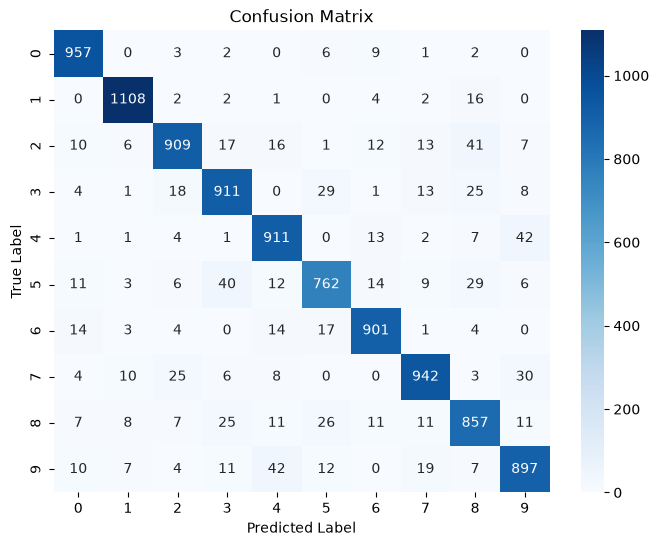

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

all_labels = []
all_predictions = []

model.eval()

correct_predictions = 0

with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        output = model(images)

        predicted = output.argmax(1)
        correct_predictions += (predicted == labels).sum().item()

        # Numpy works on CPU
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

accuracy = correct_predictions / len(test_data)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(all_labels, all_predictions)


plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

## Observation

The model achieved a **91.55% test accuracy**. 
The confusion matrix shows that the performance varied between different digits. Digit **1** was classified the best, with **1,108 correct predictions**, while digit **5** was the most difficult, with **762 correct predictions**. This suggests that the model has more difficulty distinguishing certain handwritten shapes, especially when different digits have similar visual characteristics.